<a href="https://colab.research.google.com/github/RebeccaGS/ps-analytical-26.1/blob/main/PS_Anal%C3%ADtica_26_1_grupo_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/PS/src


import pandas as pd
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import mapclassify
from shapely import wkt

path_data = os.path.join("data")
path_shape = os.path.join("data", "shapes", "lm_cisp_bd.shp")

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1N9P4RNTtE4lzCB_SPa2Ic6w-aT_u3MsW/PS/src


In [4]:
#criacao de crimes_por_cisp_ordenado - coluna de cisp (regiao do rio tipo recreio) e numero de roubos a onibus em ordem decrescente

import pandas as pd
import os

path_data = os.path.join("data")
path_shape = os.path.join("data", "shapes", "lm_cisp_bd.shp")

df_delegacia = pd.read_csv(f"{path_data}/delegacia.csv", encoding="iso-8859-1", sep= ';')
colunas_delegacia = ['cisp', 'mes', 'ano', 'roubo_em_coletivo', 'risp']

crimes_interesse = df_delegacia[colunas_delegacia]

crimes_interesse = crimes_interesse[(crimes_interesse['ano'] >= 2022) & (crimes_interesse['risp'] <= 2)] #Pos pandemia

crimes_por_cisp = crimes_interesse.groupby(['cisp'], as_index=False)[['roubo_em_coletivo']].sum() #Todas as cisps agrupadas pela soma de roubo

crimes_por_cisp_ordenado = crimes_por_cisp.sort_values(by = 'roubo_em_coletivo', ascending=False)

crimes_por_cisp_ordenado



,cisp,roubo_em_coletivo
17,21,1534
35,39,1379
13,17,1137
25,29,836
14,18,680
21,25,669
3,6,568
1,4,567
12,16,561
30,34,505


In [5]:
# unir routes.csv e trips.csv pelo route.id ---> achei lento, tentar otimizar

df_rotas = pd.read_csv(f"{path_data}/routes.csv")
colunas_rotas = ['route_id', 'route_short_name', 'route_long_name']
rotas_interesse = df_rotas[colunas_rotas]


df_trips = pd.read_csv(f"{path_data}/trips.csv")
colunas_trips = ['route_id', 'trip_headsign', 'direction_id', 'shape_id']
trips_interesse = df_trips[colunas_trips]

infos_dos_bus_com_duplicatas = rotas_interesse.merge(trips_interesse, on='route_id')
infos_dos_bus = infos_dos_bus_com_duplicatas.drop_duplicates(subset = ['route_id', 'direction_id']).copy()
infos_dos_bus.head(20)

infos_dos_bus['ida'] = (infos_dos_bus['direction_id'] == 0).astype(int)
infos_dos_bus['volta'] = (infos_dos_bus['direction_id'] == 1).astype(int)
infos_dos_bus.drop(columns='direction_id', inplace=True)


dicio_infos_dos_bus = {
    'route_short_name': 'numero',
    'route_long_name': 'descricao',
    'trip_headsign': 'nome'
}
infos_dos_bus.rename(columns=dicio_infos_dos_bus, inplace=True)



infos_dos_bus.head(20)


,route_id,numero,descricao,nome,shape_id,ida,volta
0,20000EXEC1110,ESP01,Galeão - Terminal Gentileza,Galeão,bzfm,0,1
1,20000EXEC1110,ESP01,Galeão - Terminal Gentileza,Terminal Gentileza,kv8q,1,0
177,E2024AAA0A,2024,Leblon - Aeroporto Internacional do RJ,Leblon,hf8v,0,1
178,E2024AAA0A,2024,Leblon - Aeroporto Internacional do RJ,Aeroporto Internacional,b81p,1,0
280,O0553AAP0A,SP553,Barra Sul - Rio Sul,Rio Sul,n2cd,1,0
283,O0553AAP0A,SP553,Barra Sul - Rio Sul,Rio Sul,n2cd,0,1
302,O0558AAA0A,558,Cidade de Deus - Copacabana,Copacabana,35a8,1,0
306,O0558AAA0A,558,Cidade de Deus - Copacabana,Copacabana,mzmm,0,1
499,O0552AAA0A,552,Terminal Alvorada - Rio Sul,Terminal Alvorada,a56f,1,0
503,O0552AAA0A,552,Terminal Alvorada - Rio Sul,Terminal Alvorada,a56f,0,1


In [6]:
stops = pd.read_csv(f"{path_data}/stops.csv")

stops

,feed_version,feed_start_date,feed_end_date,stop_id,stop_code,stop_name,tts_stop_name,stop_desc,stop_lat,stop_lon,zone_id,stop_url,location_type,parent_station,stop_timezone,wheelchair_boarding,level_id,platform_code,versao_modelo
0,2024-03-30,2024-03-30,2024-04-14,5148O00128C9,NaN,São Plácido,NaN,NaN,-22.917465,-43.640322,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,201d79faee763526a030ff998bebea9782efe961
1,2024-06-05,2024-06-05,2024-06-16,4128O00097C0,NaN,Novo Leblon,NaN,NaN,-23.000049,-43.384509,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,31a6853cb59b7bd67d2f865fa81c6992ac4e1435
2,2023-12-21,2023-12-21,2024-01-01,5144O00623C0,NaN,Joaquim Ribeiro,NaN,NaN,-22.929272,-43.578052,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,201d79faee763526a030ff998bebea9782efe961
3,2026-01-19,2026-01-19,2026-01-25,3065O00053C0,NaN,Dom Helder Câmara,NaN,NaN,-22.885519,-43.277384,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,f7495a359559836032529b2d93bc4eff1a079265
4,2023-11-01,2023-11-01,2023-11-30,3076O00080C9,NaN,Tanabi,NaN,NaN,-22.845770,-43.320900,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,201d79faee763526a030ff998bebea9782efe961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485879,2023-06-16,2023-06-16,2023-06-30,4132O00082C0,NaN,"Pontal, 904",NaN,NaN,-23.018640,-43.520220,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,201d79faee763526a030ff998bebea9782efe961
485880,2024-07-22,2024-07-22,2024-07-26,3076O00045C9,NaN,Guiraréia,NaN,NaN,-22.850490,-43.332050,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,f958f57d6b63df60eacf6155d8e385295d94fc65
485881,2025-11-19,2025-11-19,2025-12-20,3054O00058C0,NaN,Doutor Othon Machado,NaN,NaN,-22.868981,-43.284232,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,22d4617d5bb2889f600112473f926c3a35f27ed9
485882,2026-02-28,2026-02-28,2026-03-04,5149O00098C9,NaN,São João,NaN,NaN,-22.916247,-43.667708,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,1d892d29bfad4afa8edde52f016c57f99454e9e5


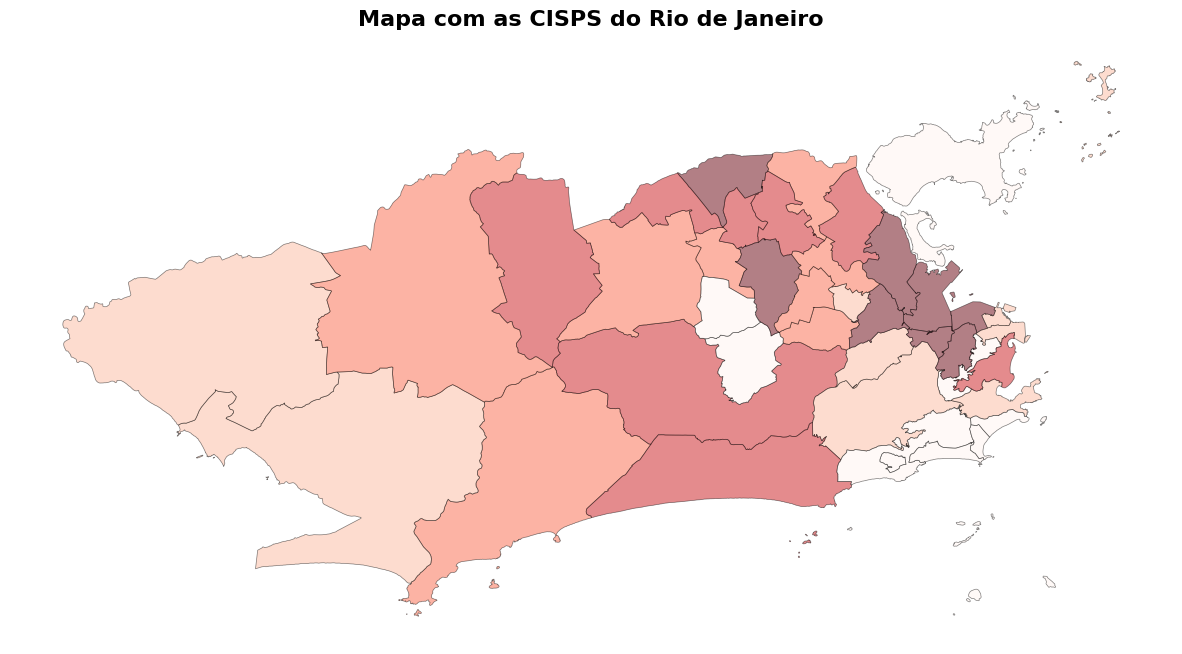

In [7]:
#criando mapa do rio com infos das localizacoes e regioes para serem desenhadas
#e quantidade de roubos em cada regiao pra fazer mapa de calor (cruzamos com crimes_por_cisp_ordenado)

import geopandas as gpd
import matplotlib.pyplot as plt
import mapclassify

mapa_cisp = gpd.read_file(path_shape)

mapa_cisp_final = mapa_cisp.merge(crimes_por_cisp_ordenado, on='cisp')
fig, ax = plt.subplots(figsize=(15, 8))

mapa_cisp_final.plot(ax=ax, edgecolor='black', linewidth=0.5, column='roubo_em_coletivo', cmap='Reds', scheme='quantiles', k=5, alpha=0.5)

ax.set_title('Mapa com as CISPS do Rio de Janeiro', fontsize=16, fontweight='bold')
ax.axis('off')

plt.show()

<Axes: >

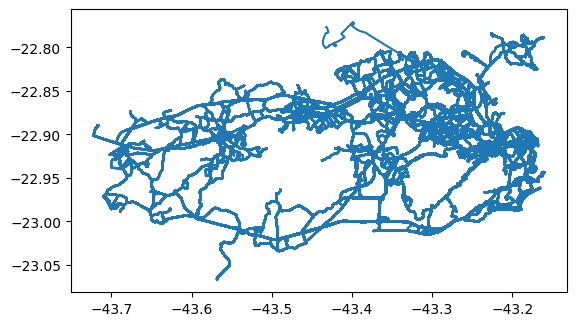

In [8]:
#criando linhas por onde os onibus passam

import pandas as pd
import geopandas as gpd
from shapely import wkt

shapes = pd.read_csv(f"{path_data}/shapes_geom.csv")

shapes_filtrados = shapes[shapes['shape_id'].isin(infos_dos_bus['shape_id'])]
bus_com_trajeto = shapes_filtrados.merge(infos_dos_bus, on='shape_id')

#converte o texto de linestring() em linha matematica p gpd entender que da pra desenhar linha de rota
bus_com_trajeto['geometry'] = bus_com_trajeto['shape'].apply(wkt.loads)

colunas_inuteis = ['feed_version', 'feed_start_date', 'feed_end_date', 'shape_distance', 'start_pt', 'end_pt', 'versao_modelo', 'shape']
bus_com_trajeto.drop(columns=colunas_inuteis, inplace=True, errors='ignore')

linhas_onibus_geo = gpd.GeoDataFrame(bus_com_trajeto, geometry='geometry', crs="EPSG:4326")



#bus_com_trajeto.head()
linhas_onibus_geo.plot()

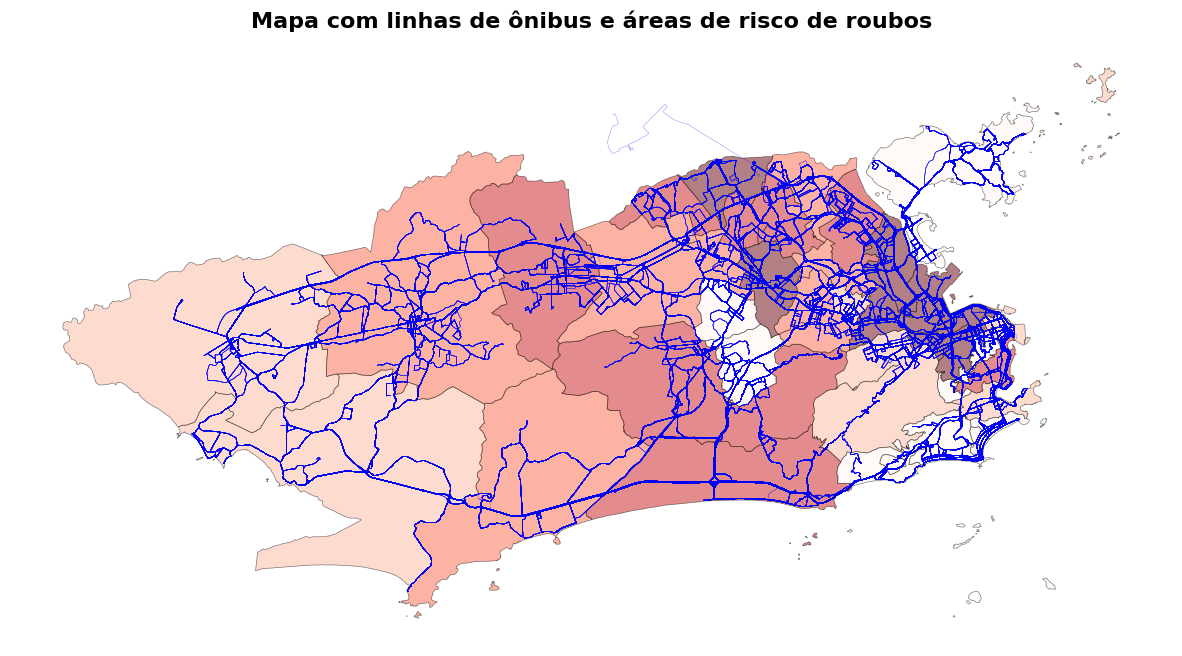

In [9]:
#mapa com as linhas

import matplotlib.pyplot as plt

fig,ax = plt.subplots(figsize=(15,8))
mapa_cisp_final.plot(ax=ax, edgecolor='black', linewidth=0.5, column='roubo_em_coletivo', cmap='Reds', scheme='quantiles', k=5, alpha=0.5)
linhas_onibus_geo.plot(ax=ax, color='blue', linewidth=0.4, alpha=0.4)
ax.set_title('Mapa com linhas de ônibus e áreas de risco de roubos', fontsize=16, fontweight='bold')
ax.axis('off')
plt.show()

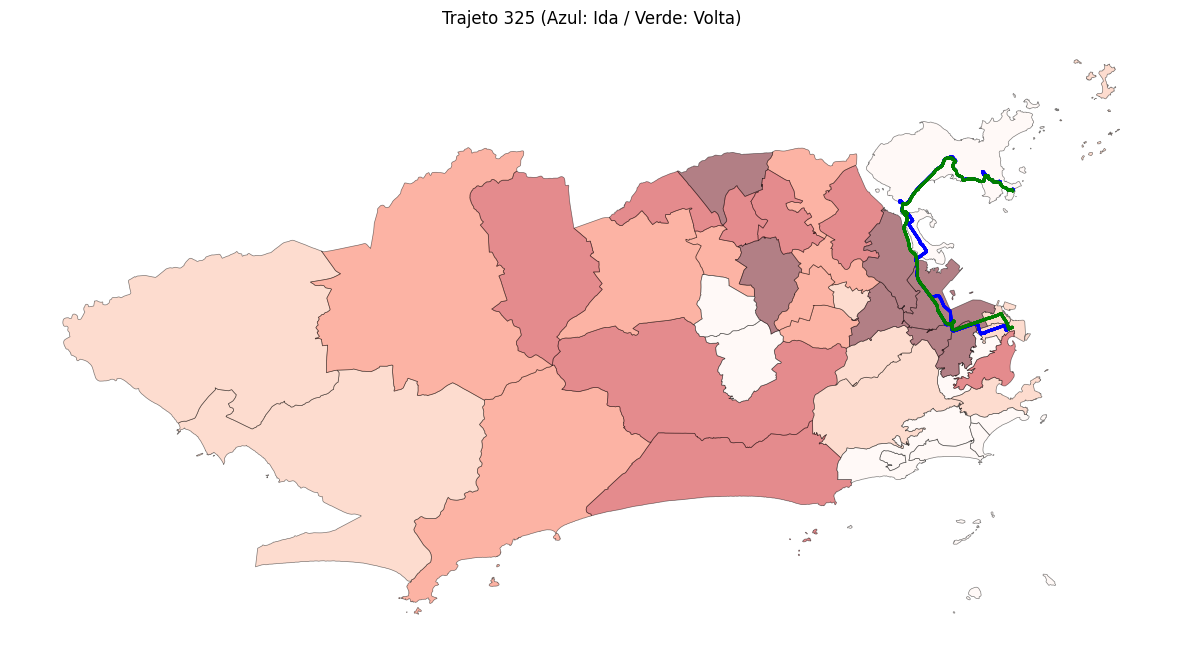

In [10]:
#plotar apenas linha de um onibus especifico (usei pq 325 tava dando 10 de risco em uma analise e queria ter uma visao melhor da rota dele pra entender o problema)

import matplotlib.pyplot as plt

linha_325 = linhas_onibus_geo[linhas_onibus_geo['numero'] == '325']
ida = linha_325[linha_325['ida'] == 1]
volta = linha_325[linha_325['volta'] == 1]

fig, ax = plt.subplots(figsize=(15, 8))
mapa_cisp_final.plot(ax=ax, edgecolor='black', linewidth=0.5, column='roubo_em_coletivo', cmap='Reds', scheme='quantiles', k=5, alpha=0.5)
ida.plot(ax=ax, color='blue', linewidth=2, label='Ida')
volta.plot(ax=ax, color='green', linewidth=2, label='Volta')

ax.set_title('Trajeto 325 (Azul: Ida / Verde: Volta)')
ax.axis('off')
plt.show()


In [15]:
#classificando nivel de risco de cada onibus

'''
classificacao feita pelo pd.qcut se mostrou nao ser a melhor forma -  agrupava de 10% em 10% (10% iniciais nota 1, 10% seguintes n2)
risco_por_linha['nota_risco'] = pd.qcut(risco_por_linha['exposicao_roubo_total'], 10, labels=False) + 1
'''

import pandas as pd
import numpy as np
import geopandas as gpd

onibus_com_crimes_completo = gpd.sjoin(linhas_onibus_geo, mapa_cisp_final, predicate='intersects')

onibus_com_crimes = onibus_com_crimes_completo.drop_duplicates(subset=['route_id', 'ida', 'volta', 'cisp'])

risco_por_linha = onibus_com_crimes.groupby(['route_id', 'ida', 'volta', 'numero'],as_index=False)['roubo_em_coletivo'].sum()

risco_por_linha.rename(columns={'roubo_em_coletivo': 'exposicao_roubo_total'}, inplace=True)

risco_por_linha['nota_risco'], limites = pd.cut(risco_por_linha['exposicao_roubo_total'],bins=5,labels=[1, 2, 3, 4, 5],retbins=True)

limites
display(risco_por_linha['nota_risco'].value_counts().sort_index())

resultado = risco_por_linha[risco_por_linha['numero'].isin(['696', '325', '324'])]
display(resultado)

'''
Mudar cores -

Esquece usuario comum - focar na Política pública(!!!!!!!)

5 - perigoso - fica em casa irmao
4 - alto risco - guarda o celular
3 - medio risco - um olho aberto outro fechado
2 - baixo risco - pode usar o celular
1 - seguro - cochila a vontade

No relatório - Chatbox com gemini
'''

,count
nota_risco,
1,554
2,261
3,222
4,75
5,108


,route_id,ida,volta,numero,exposicao_roubo_total,nota_risco
383,O0324AAA0A,0,1,324,4750,3
384,O0324AAA0A,1,0,324,4750,3
389,O0325AAA0A,0,1,325,4964,3
390,O0325AAA0A,1,0,325,4786,3
785,O0696AAA0A,0,1,696,2434,2
786,O0696AAA0A,1,0,696,2663,2


'\nperigoso - fica em casa irmao\nalto risco - guarda o celular\nmedio risco - um olho aberto outro fechado\nbaixo risco - pode usar o celular\nseguro - cochila a vontade\n'

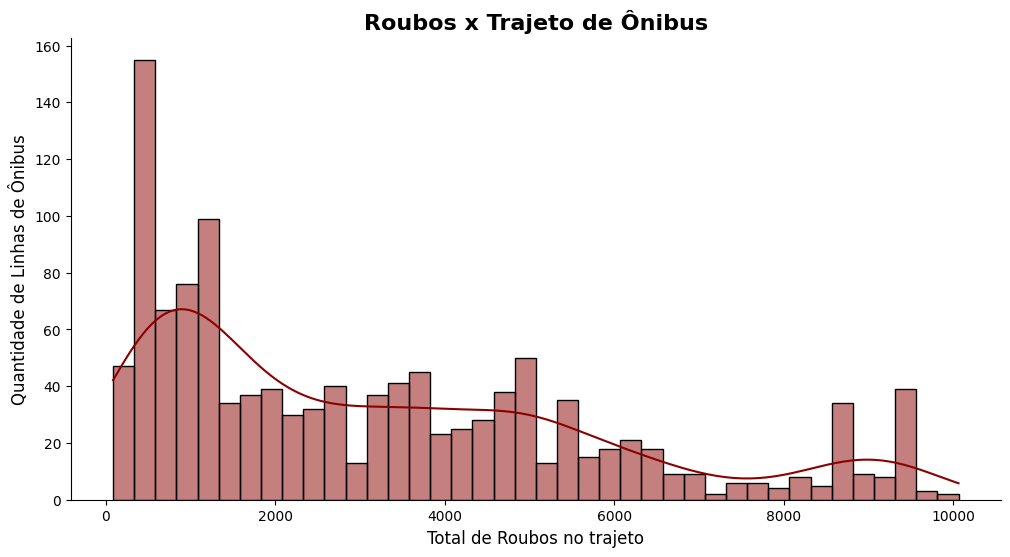

In [12]:
#p analisar qual metodo melhor - pd.qcut se mostrou ruim pq mt concentraçao em um ponto

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(risco_por_linha['exposicao_roubo_total'], bins=40, kde=True, color='darkred', ax=ax)

ax.set_title('Roubos x Trajeto de Ônibus', fontsize=16, fontweight='bold')
ax.set_xlabel('Total de Roubos no trajeto', fontsize=12)
ax.set_ylabel('Quantidade de Linhas de Ônibus', fontsize=12)
ax.spines['top'].set_visible(False)#tirar linhas
ax.spines['right'].set_visible(False)

plt.show()

